# INARA Source Data Explorer

This notebook explains and samples the raw input files used by the INARA pipeline.

### Files covered
| File | Role |
|------|------|
| `pyatmos_summary.csv` | Master index — one row per simulated planet |
| `dir_0.tar.gz … dir_9.tar.gz` | ~7,800 simulation samples each |
| `Dir_alpha.tar.gz` | ~46,000 additional samples |

Inside each tar.gz, every planet is a hash-named directory containing 4 key files:
- `parsed_clima_final.npy.npz` — CLIMA atmospheric profile (MODEL INPUT)
- `parsed_photochem_mixing_ratios.npy.npz` — Chemical species concentrations (MODEL TARGETS)
- `mixing_ratios.dat` — N₂ surface concentration (12th target)
- `run_metadata.json` — Simulation setup conditions

In [12]:
import pandas as pd
import numpy as np
import tarfile, json, io
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

RAW_DIR   = '/Users/bhalchandra/Downloads/full_inara'
ARCHIVE_0 = RAW_DIR + '/dir_0.tar.gz'
SUMMARY   = RAW_DIR + '/pyatmos_summary.csv'

print('Setup complete.')

Setup complete.


---
## 1. pyatmos_summary.csv — Master Index

**What it is:** One row per planet simulation. Contains the input parameters used to set up each run and the resulting equilibrium concentrations for 5 key molecules. Used solely for random sampling — which planets to extract.

**18 columns in 3 groups:**

| Group | Columns | Meaning |
|-------|---------|--------|
| Identifer | `hash` | MD5 hash — unique planet ID, matches directory name in archives |
| Simulation outputs | `concentration_CH4/CO2/H2/H2O/O2` | Final equilibrium surface concentrations from the photochem model (VMR, 0–1 scale) |
| Input fluxes | `flux_CH4/CO2/H2/H2O/O2` | Surface emission/absorption fluxes (molecules/cm²/s). Positive = emitted, negative = absorbed |
| Initial conditions | `input_CH4/CO2/H2/H2O/O2` | Starting concentrations set before running photochem equilibrium |
| Physical setup | `pressure_bar`, `temperature_kelvin` | Surface pressure and temperature for this simulation |

In [13]:
summary = pd.read_csv(SUMMARY)
print(f'Rows: {len(summary):,}   Columns: {len(summary.columns)}')
print(f'Columns: {list(summary.columns)}')
summary.head(5)

Rows: 124,314   Columns: 18
Columns: ['concentration_CH4', 'concentration_CO2', 'concentration_H2', 'concentration_H2O', 'concentration_O2', 'flux_CH4', 'flux_CO2', 'flux_H2', 'flux_H2O', 'flux_O2', 'hash', 'input_CH4', 'input_CO2', 'input_H2', 'input_H2O', 'input_O2', 'pressure_bar', 'temperature_kelvin']


,concentration_CH4,concentration_CO2,concentration_H2,concentration_H2O,concentration_O2,flux_CH4,flux_CO2,flux_H2,flux_H2O,flux_O2,hash,input_CH4,input_CO2,input_H2,input_H2O,input_O2,pressure_bar,temperature_kelvin
0,0.010000,0.03,5.000000e-02,0.0123,0.22,1.630000e+14,-1.600000e+14,8.300000e+14,-7.860000e+12,7.650000e+14,fce1393235c17c238c7a467650949b88,0.010000,0.03,5.000000e-02,0.0400,0.22,1.0629,320.29
1,0.030000,0.01,8.100000e-08,0.0123,0.16,1.210000e+15,-1.210000e+15,-9.800000e+12,-1.390000e+13,2.580000e+15,f4022a3d71e63825ed64c463f1eb8b98,0.030000,0.01,8.100000e-08,0.0123,0.16,1.1183,320.26
2,0.020000,0.01,7.900000e-08,0.0123,0.21,9.780000e+14,-9.760000e+14,-9.680000e+12,-6.710000e+12,2.070000e+15,b230150494f683b7ef88aa4149fe7c7f,0.020000,0.01,7.900000e-08,0.4500,0.21,1.1036,320.21
3,0.000002,0.04,8.700000e-08,0.0123,0.14,1.440000e+11,2.940000e+12,-4.790000e+08,3.540000e+12,8.810000e+11,f7a42e7a292cb4fca946a491cf04b22c,0.000002,0.04,8.700000e-08,0.1500,0.14,1.0685,313.87
4,0.020000,0.02,8.200000e-08,0.0123,0.20,9.760000e+14,-9.730000e+14,-9.750000e+12,-6.950000e+12,2.070000e+15,f3d58d46c9778b8aeee07dbd8a821e2b,0.020000,0.02,8.200000e-08,0.4000,0.20,1.1177,322.48


In [14]:
# Statistical overview
summary.describe().round(4)

,concentration_CH4,concentration_CO2,concentration_H2,concentration_H2O,concentration_O2,flux_CH4,flux_CO2,flux_H2,flux_H2O,flux_O2,input_CH4,input_CO2,input_H2,input_H2O,input_O2,pressure_bar,temperature_kelvin
count,124314.0000,124314.0000,124314.0000,124314.0000,124314.0000,1.243140e+05,1.243140e+05,1.243140e+05,1.243140e+05,1.243140e+05,124314.0000,124314.0000,124314.0000,124314.0000,124314.0000,124314.0000,124314.0000
mean,0.0160,0.0272,0.0111,0.0123,0.2121,5.658597e+14,-5.630317e+14,1.570561e+14,-5.884775e+12,1.283378e+15,0.0160,0.0272,0.0111,0.1026,0.2121,1.0867,316.1585
std,0.0179,0.0284,0.0225,0.0000,0.0714,4.807145e+14,4.803728e+14,3.108504e+14,9.854423e+12,1.029946e+15,0.0179,0.0284,0.0225,0.1165,0.0714,0.0378,9.2950
min,0.0000,0.0004,0.0000,0.0123,0.0200,4.450000e+09,-2.000000e+15,-1.500000e+13,-3.840000e+13,5.470000e+11,0.0000,0.0004,0.0000,0.0100,0.0200,1.0131,251.2400
25%,0.0000,0.0004,0.0000,0.0123,0.1800,1.660000e+11,-9.620000e+14,-9.030000e+12,-1.150000e+13,1.240000e+14,0.0000,0.0004,0.0000,0.0123,0.1800,1.0604,311.4600
50%,0.0100,0.0200,0.0000,0.0123,0.2100,5.940000e+14,-5.900000e+14,-4.860000e+12,-1.960000e+12,1.290000e+15,0.0100,0.0200,0.0000,0.0500,0.2100,1.0856,318.2300
75%,0.0200,0.0400,0.0100,0.0123,0.2400,9.650000e+14,-4.840000e+11,1.790000e+14,2.150000e+12,2.070000e+15,0.0200,0.0400,0.0100,0.1500,0.2400,1.1152,322.9700
max,0.1300,0.4000,0.1900,0.0124,0.9000,2.000000e+15,3.200000e+13,1.480000e+15,5.430000e+12,4.280000e+15,0.1300,0.4000,0.1900,0.8000,0.9000,1.1941,332.0500


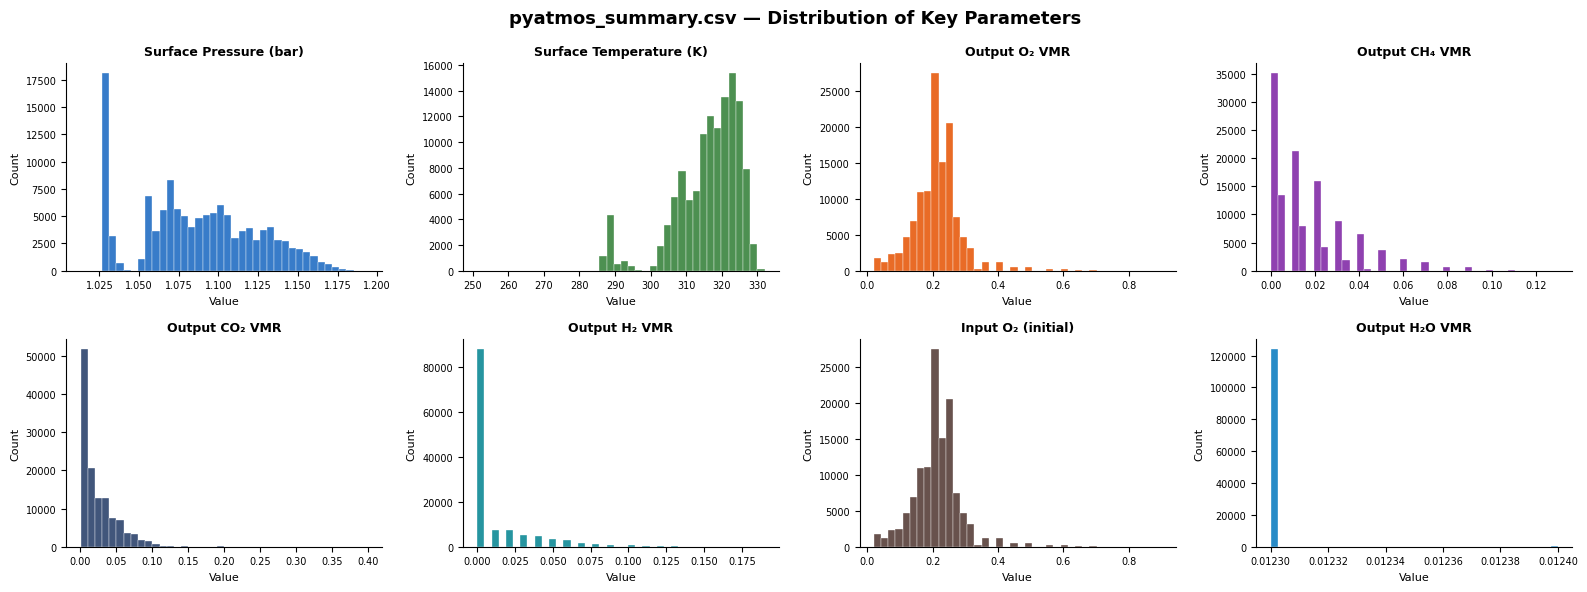

In [15]:
# Distribution of key input parameters
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('pyatmos_summary.csv — Distribution of Key Parameters', fontsize=13, fontweight='bold')

cols = [
    ('pressure_bar',          'Surface Pressure (bar)',       '#1565C0'),
    ('temperature_kelvin',    'Surface Temperature (K)',      '#2E7D32'),
    ('concentration_O2',      'Output O₂ VMR',                '#E65100'),
    ('concentration_CH4',     'Output CH₄ VMR',               '#7B1FA2'),
    ('concentration_CO2',     'Output CO₂ VMR',               '#1F3864'),
    ('concentration_H2',      'Output H₂ VMR',                '#00838F'),
    ('input_O2',              'Input O₂ (initial)',           '#4E342E'),
    ('concentration_H2O',     'Output H₂O VMR',               '#0277BD'),
]

for ax, (col, label, color) in zip(axes.flat, cols):
    ax.hist(summary[col], bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 2. Archive Structure — What's Inside a tar.gz

Each archive contains ~7,800 (dir_0–9) or ~46,000 (Dir_alpha) planet simulation directories.  
Each directory is named by its MD5 hash and contains **22 files**, of which only 4 are used.

In [16]:
from collections import defaultdict

with tarfile.open(ARCHIVE_0, 'r:gz') as tf:
    all_members = [m.name for m in tf.getmembers() if m.isfile()]

# Count unique hashes
all_hashes = sorted({m.split('/')[1] for m in all_members})
print(f'dir_0.tar.gz — {len(all_members):,} total file entries')
print(f'Unique planet simulations: {len(all_hashes):,}')

# Build a map of hash -> set of filenames
file_map = defaultdict(set)
for m in all_members:
    parts = m.split('/')
    if len(parts) >= 3:
        file_map[parts[1]].add(parts[-1])

# Pick first hash that has all 4 required files
NEEDED = {'parsed_clima_final.npy.npz',
          'parsed_photochem_mixing_ratios.npy.npz',
          'mixing_ratios.dat',
          'run_metadata.json'}
complete_hashes = [h for h in all_hashes if NEEDED.issubset(file_map[h])]
print(f'Hashes with all 4 required files: {len(complete_hashes):,} of {len(all_hashes):,}')

sample_hash = complete_hashes[0]  # guaranteed to have all 4 files

sample_files = sorted([m.split('/')[-1] for m in all_members if sample_hash in m])
print(f'\nFiles for sample {sample_hash[:12]}...:')
for f in sample_files:
    used = '  ← USED by pipeline' if f in NEEDED else ''
    print(f'  {f}{used}')


dir_0.tar.gz — 162,616 total file entries
Unique planet simulations: 7,828
Hashes with all 4 required files: 3,028 of 7,828

Files for sample 000027d603d7...:
  Clima_log.txt
  Photo_log.txt
  TempIn.dat
  TempOut.dat
  clima_allout.tab
  in.dist
  input_clima.dat
  mixing_ratios.dat  ← USED by pipeline
  out.dist
  out.out
  parsed_clima_final.csv
  parsed_clima_final.npy.npz  ← USED by pipeline
  parsed_clima_initial.csv
  parsed_clima_initial.npy.npz
  parsed_clima_iterations.csv
  parsed_clima_iterations.npy.npz
  parsed_photochem_fluxes.csv
  parsed_photochem_fluxes.npy.npz
  parsed_photochem_mixing_ratios.csv
  parsed_photochem_mixing_ratios.npy.npz  ← USED by pipeline
  run_metadata.json  ← USED by pipeline
  species.dat


---
## 3. run_metadata.json — Simulation Setup Conditions

**What it is:** The "control panel" for one simulation run — what the researcher set as inputs before CLIMA+Photochem ran.

**Key fields used by pipeline** (saved to `aux_params.npy`):

| Field | Unit | Meaning |
|-------|------|--------|
| `flux_CH4/CO/CO2/H2O/NH3/O3` | molecules/cm²/s | Surface emission (+) or absorption (-) flux for each gas |
| `pressure` | bar | Surface atmospheric pressure |
| `temperature` | K | Surface temperature |
| `input_species_concentrations` | VMR | Starting concentrations before equilibrium |

**Not used in model training** — these are the *causes*, not the *effects* (the CLIMA profile is the effect, and that's what the CNN sees).

In [17]:
with tarfile.open(ARCHIVE_0, 'r:gz') as tf:
    meta_path = f'dir_0/{sample_hash}/run_metadata.json'
    buf = tf.extractfile(meta_path)
    meta = json.loads(buf.read())

print('run_metadata.json — full content for sample', sample_hash[:12], '...')
print(json.dumps(meta, indent=2))

run_metadata.json — full content for sample 000027d603d7 ...
{
  "atmos_run_duration": 1512,
  "atmos_start_time": 1533987228,
  "clima_duration": 1428,
  "current_hash": "000027d603d74921a5e706ebf9d0986e",
  "flux_CH4": 9710000000.0,
  "flux_CO": 370000000000.0,
  "flux_CO2": 3920000000000.0,
  "flux_H2O": 2840000000000.0,
  "flux_NH3": -0.0,
  "flux_O3": 60.8,
  "input_max_clima_iterations": 400,
  "input_max_photochem_iterations": 10000,
  "input_species_concentrations": {
    "CH4": 1.63e-06,
    "CO2": 0.05,
    "H2": 0.01,
    "H2O": 0.08,
    "O2": 0.19
  },
  "photochem_duration": 84,
  "photochem_iterations": 361,
  "pressure": 1.0371,
  "previous_hash": "721ead83b5798c7e4f2bb16769bdc7dc",
  "run_iteration_call": 23,
  "temperature": 310.68,
  "write_logfiles": true
}


---
## 4. parsed_clima_final.csv / .npy.npz — MODEL INPUT FEATURES

**What it is:** The CLIMA radiative-convective model output. A vertical profile of 12 physical atmospheric variables at 101 altitude levels.

**Shape:** `(101, 12)` → transposed to `(12, 101)` for CNN input  
**Axis meaning:** rows = altitude levels (0 = top of atmosphere, 100 = surface)

| Column | Variable | Physical Meaning |
|--------|----------|------------------|
| J | Photolysis rate index | Altitude layer index (1–101), proxy for UV intensity |
| P | Pressure | Atmospheric pressure at this altitude (bar) |
| ALT | Altitude | Height above surface (km) |
| T | Temperature | Air temperature (K) |
| CONVEC | Convection | Convective energy flux (energy mixing) |
| DT | ΔTemperature | Temperature change per solver timestep |
| TOLD | T previous | Temperature from previous solver iteration |
| FH₂O | H₂O flux | Radiative flux from water vapour |
| FSAVE | Saved flux | Total net radiative flux |
| FO₃ | O₃ flux | UV-shielding flux from ozone |
| TCOOL | Cooling rate | Radiative cooling at this level |
| THEAT | Heating rate | Radiative heating at this level |

In [18]:
CLIMA_COLS = ['J', 'P', 'ALT', 'T', 'CONVEC', 'DT', 'TOLD', 'FH2O', 'FSAVE', 'FO3', 'TCOOL', 'THEAT']

with tarfile.open(ARCHIVE_0, 'r:gz') as tf:
    # Load the CSV version for easy reading
    clima_csv_path = f'dir_0/{sample_hash}/parsed_clima_final.csv'
    buf = tf.extractfile(clima_csv_path)
    clima_df = pd.read_csv(buf)
    clima_df.columns = CLIMA_COLS

    # Also load the npz to show actual shape used by model
    clima_npz_path = f'dir_0/{sample_hash}/parsed_clima_final.npy.npz'
    buf2 = tf.extractfile(clima_npz_path)
    clima_arr = np.load(io.BytesIO(buf2.read()))['arr_0']  # (101, 12)

print(f'Shape in file:   {clima_arr.shape}  (altitude levels × CLIMA variables)')
print(f'Shape for CNN:   {clima_arr.T.shape}  (channels × sequence_length) after transpose')
print()
print('First 5 rows (surface layers, high altitude):')
clima_df.head(5).round(6)

Shape in file:   (101, 12)  (altitude levels × CLIMA variables)
Shape for CNN:   (12, 101)  (channels × sequence_length) after transpose

First 5 rows (surface layers, high altitude):


,J,P,ALT,T,CONVEC,DT,TOLD,FH2O,FSAVE,FO3,TCOOL,THEAT
0,1,0.000008,60.036,78.384,0.0,0.006954,78.377,0.005050,0.005050,0.0,-37.0040,37.567
1,2,0.000009,59.575,89.549,0.0,1.137500,89.533,0.002022,0.002022,0.0,65.9330,25.996
2,3,0.000011,59.065,97.855,0.0,0.640500,97.831,0.000811,0.000811,0.0,31.5190,20.244
3,4,0.000014,58.521,103.410,0.0,0.432870,103.370,0.000327,0.000327,0.0,15.6420,19.341
4,5,0.000016,57.957,107.270,0.0,0.314040,107.230,0.000133,0.000133,0.0,7.5747,17.805


In [19]:
print('Last 5 rows (surface layer at row 100):')
clima_df.tail(5).round(6)

Last 5 rows (surface layer at row 100):


,J,P,ALT,T,CONVEC,DT,TOLD,FH2O,FSAVE,FO3,TCOOL,THEAT
96,97,0.87131,1.55130,305.95,1.0,-0.000068,305.95,0.038567,0.038567,0.0,-0.78129,0.77773
97,98,0.91736,1.09560,307.35,1.0,-0.000068,307.35,0.041582,0.041582,0.0,-0.61560,0.78176
98,99,0.96446,0.65017,308.71,0.0,-0.000068,308.71,0.044843,0.044844,0.0,-0.57306,0.79368
99,100,1.01250,0.21516,310.02,0.0,-0.000068,310.02,0.048437,0.048438,0.0,-0.53724,0.81586
100,101,1.03710,0.00000,310.68,1.0,-0.000068,310.68,0.050239,0.050239,0.0,0.00000,0.00000


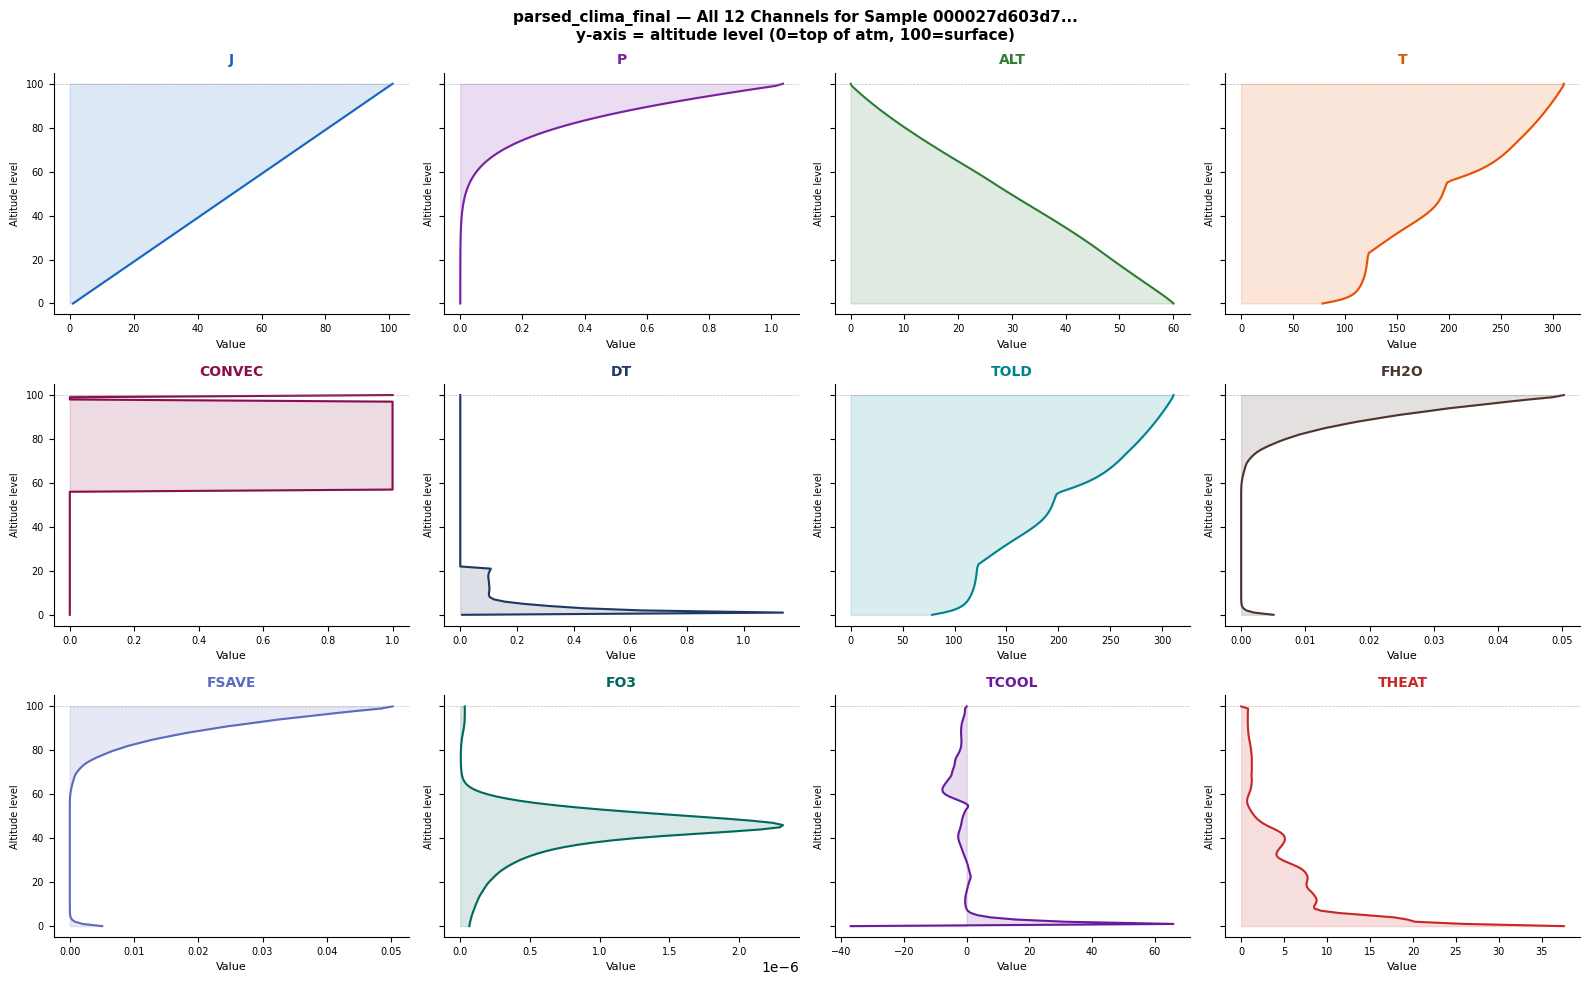

Note: Level 100 = surface (highest pressure). Level 0 = top of atmosphere.


In [20]:
# Visualise the 12 CLIMA channels as altitude profiles
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=True)
fig.suptitle(
    f'parsed_clima_final — All 12 Channels for Sample {sample_hash[:12]}...\n'
    'y-axis = altitude level (0=top of atm, 100=surface)',
    fontsize=11, fontweight='bold')

colors = ['#1565C0','#7B1FA2','#2E7D32','#E65100',
          '#880E4F','#1F3864','#00838F','#4E342E',
          '#5C6BC0','#00695C','#6A1B9A','#C62828']

alt = clima_df['ALT'].values

for ax, col, color in zip(axes.flat, CLIMA_COLS, colors):
    vals = clima_df[col].values
    ax.plot(vals, range(101), color=color, lw=1.5)
    ax.fill_betweenx(range(101), vals, alpha=0.15, color=color)
    ax.set_title(col, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Altitude level', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axhline(100, color='grey', lw=0.5, ls='--', alpha=0.5)  # surface

plt.tight_layout()
plt.show()
print('Note: Level 100 = surface (highest pressure). Level 0 = top of atmosphere.')

---
## 5. parsed_photochem_mixing_ratios.csv / .npy.npz — MODEL TARGET (11 Molecules)

**What it is:** Output of the photochemistry model. Chemical equilibrium concentrations for 66 atmospheric species at each altitude. Only the **surface row (row 0)** and **11 specific column indices** are extracted as targets.

**Shape:** `(102, 66)` — 102 altitude rows × 66 chemical species  
**Used:** Row 0 only (surface layer)

**Why 102 rows?** The photochem grid has 101 atmosphere levels + 1 extra metadata row at index 0 (contains altitude Z value 25000 = ground level marker).

| Molecule | Column Index | Scientific Role |
|----------|----|----------------|
| O₂  | 3  | Biosignature — photosynthesis product |
| H₂O | 4  | Water — habitability marker |
| H₂  | 9  | Primordial hydrogen — atmospheric escape |
| CO  | 10 | Carbon monoxide — abiotic chemistry |
| CH₄ | 17 | Methane — biological or volcanic |
| H₂S | 24 | Hydrogen sulphide — volcanic activity |
| SO₂ | 28 | Sulphur dioxide — volcanic/industrial |
| O₃  | 37 | Ozone — UV shield, O₂ proxy |
| N₂O | 42 | Nitrous oxide — biological N-cycle |
| NH₃ | 47 | Ammonia — biological metabolism |
| CO₂ | 48 | Carbon dioxide — greenhouse gas |
| **N₂** | **mixing_ratios.dat** | Background carrier gas — parsed separately |

In [21]:
PHOTOCHEM_COLS = {
    'H2O': 4, 'CO2': 48, 'O2': 3, 'O3': 37, 'CH4': 17,
    'N2O': 42, 'CO': 10, 'H2': 9, 'H2S': 24, 'SO2': 28, 'NH3': 47
}

with tarfile.open(ARCHIVE_0, 'r:gz') as tf:
    # CSV version
    pc_csv_path = f'dir_0/{sample_hash}/parsed_photochem_mixing_ratios.csv'
    buf = tf.extractfile(pc_csv_path)
    pc_df = pd.read_csv(buf)

    # NPZ version
    pc_npz_path = f'dir_0/{sample_hash}/parsed_photochem_mixing_ratios.npy.npz'
    buf2 = tf.extractfile(pc_npz_path)
    pc_arr = np.load(io.BytesIO(buf2.read()))['arr_0']  # (102, 66)

print(f'Full array shape: {pc_arr.shape}  (altitude rows × 66 chemical species)')
print(f'Columns in CSV: {list(pc_df.columns)}')
print()

# Extract the 11 target molecules from surface row
surface = pc_arr[0]   # row 0 = surface
LOG_FLOOR = -40.0

targets = {}
for mol, col in PHOTOCHEM_COLS.items():
    vmr = float(surface[col])
    log_vmr = max(LOG_FLOOR, np.log10(abs(vmr)) if vmr > 0 else LOG_FLOOR)
    targets[mol] = {'VMR (raw)': vmr, 'log₁₀ VMR': round(log_vmr, 4)}

targets_df = pd.DataFrame(targets).T
targets_df.index.name = 'Molecule'
print(f'Extracted surface concentrations for sample {sample_hash[:12]}...')
targets_df

Full array shape: (102, 66)  (altitude rows × 66 chemical species)
Columns in CSV: ['Unnamed: 0', 'Z', 'O', 'O2', 'H2O', 'H', 'OH', 'HO2', 'H2O2', 'H2', 'CO', 'HCO', 'H2CO', 'CH3O', 'CH2OH', 'CH3O2', 'CH3OOH', 'CH4', 'CH3', 'C2H6', 'Z.1', 'NO', 'NO2', 'HNO', 'H2S', 'HS', 'S', 'SO', 'SO2', 'H2SO4', 'HSO', 'S2', 'S4', 'S8', 'SO3', 'OCS', 'S3', 'O3', 'HNO3', 'Z.2', 'N', 'NO3', 'N2O', 'HO2NO2', 'N2O5', 'NH', 'NH2', 'NH3', 'CO2', 'CS', 'CS2', 'HCS', 'C2H6S', 'C2H5S', 'C2H5SO', 'C2H5SO2', 'CH3S', 'CH3SO', 'Z.3', 'CH3SO2', 'CH3SO3', 'CH4SO2', 'C2H6SO', 'C2H7SO', 'SO4AER', 'S8AER']

Extracted surface concentrations for sample 000027d603d7...


,VMR (raw),log₁₀ VMR
Molecule,,
H2O,1.230000e-02,-1.9101
CO2,5.000000e-02,-1.3010
O2,1.900000e-01,-0.7212
O3,3.260000e-08,-7.4868
CH4,1.630000e-06,-5.7878
N2O,1.770000e-07,-6.7520
CO,2.180000e-06,-5.6615
H2,1.000000e-02,-2.0000
H2S,1.270000e-10,-9.8962


---
## 6. mixing_ratios.dat — N₂ Surface Concentration

**What it is:** A plain text file listing the surface mixing ratio of key gases including N₂ (nitrogen). N₂ is the background carrier gas — it fills whatever atmosphere is not accounted for by the reactive species. It is not in the photochem array because it doesn't react.

**Format:** Each line: `value   !SpeciesName`  
**Parsing rule:** Match the line ending exactly in `!Nitrogen` (not `!Nitrogen Dioxide`)

In [22]:
with tarfile.open(ARCHIVE_0, 'r:gz') as tf:
    mix_path = f'dir_0/{sample_hash}/mixing_ratios.dat'
    buf = tf.extractfile(mix_path)
    lines = buf.read().decode().splitlines()

print('mixing_ratios.dat — full content:')
for line in lines:
    parts = line.strip().split()
    is_n2 = (len(parts) >= 2
             and parts[1] == '!Nitrogen'
             and 'Dioxide' not in line
             and 'dioxide' not in line)
    marker = '  ← N₂ extracted here' if is_n2 else ''
    print(f'  {line}{marker}')

# Parse N2 — match '!Nitrogen' but not '!Nitrogen Dioxide'
n2_vmr = None
for line in lines:
    parts = line.strip().split()
    if (len(parts) >= 2
            and parts[1] == '!Nitrogen'
            and 'Dioxide' not in line
            and 'dioxide' not in line):
        n2_vmr = float(parts[0])
        break

if n2_vmr is None:
    # Fallback: N2 is the complement of major detectable gases
    print('WARNING: !Nitrogen line not found, using fallback N2 = 0.79')
    n2_vmr = 0.79

import numpy as np
print(f'\nParsed N\u2082 VMR : {n2_vmr}')
print(f'log\u2081\u2080 N\u2082 VMR: {np.log10(n2_vmr):.4f}')


mixing_ratios.dat — full content:
   1.000E-02          !Argon
   1.630E-06          !Methane
   1.661E-28          !Ethane
   5.000E-02          !Carbon Dioxide
   8.000E-01          !Nitrogen  ← N₂ extracted here
   1.900E-01          !Oxygen
   1.000E-02          !Hydrogen
   1.250E-70          !Nitrogen Dioxide
   28                 !Tropopause layer

Parsed N₂ VMR : 0.8
log₁₀ N₂ VMR: -0.0969


---
## 7. Full Target Vector — All 12 Molecules

Combining the 11 molecules from photochem + N₂ from mixing_ratios.dat gives the complete 12-element target vector stored in `molecules.npy`.

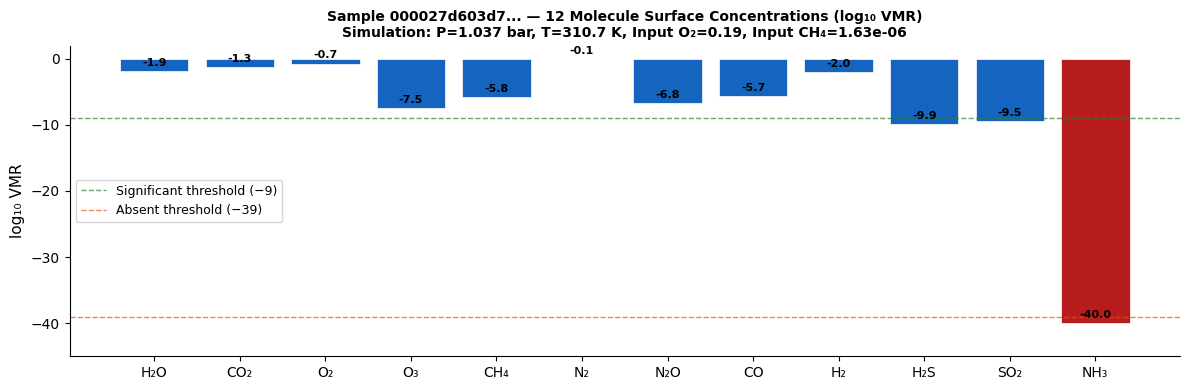


12-element target vector (log₁₀ VMR):
  H2O    -1.9101
  CO2    -1.3010
  O2     -0.7212
  O3     -7.4868
  CH4    -5.7878
  N2     -0.0969
  N2O    -6.7520
  CO     -5.6615
  H2     -2.0000
  H2S    -9.8962
  SO2    -9.4724
  NH3   -40.0000


In [23]:
MOLECULE_NAMES = ['H2O','CO2','O2','O3','CH4','N2','N2O','CO','H2','H2S','SO2','NH3']
MOLECULE_LABELS = ['H₂O','CO₂','O₂','O₃','CH₄','N₂','N₂O','CO','H₂','H₂S','SO₂','NH₃']

# Assemble full vector
mol_vals = []
for mol in MOLECULE_NAMES:
    if mol == 'N2':
        vmr = n2_vmr
    else:
        col = PHOTOCHEM_COLS[mol]
        vmr = float(surface[col])
    log_vmr = max(LOG_FLOOR, np.log10(abs(vmr)) if vmr > 0 else LOG_FLOOR)
    mol_vals.append(log_vmr)

mol_arr = np.array(mol_vals)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#1565C0' if v > -10 else '#E65100' if v > -30 else '#B71C1C'
          for v in mol_arr]
bars = ax.bar(MOLECULE_LABELS, mol_arr, color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(-9,  color='#2E7D32', ls='--', lw=1, alpha=0.7, label='Significant threshold (−9)')
ax.axhline(-39, color='#E65100', ls='--', lw=1, alpha=0.7, label='Absent threshold (−39)')
ax.set_ylabel('log₁₀ VMR', fontsize=11)
ax.set_title(
    f'Sample {sample_hash[:12]}... — 12 Molecule Surface Concentrations (log₁₀ VMR)\n'
    f'Simulation: P={meta["pressure"]:.3f} bar, T={meta["temperature"]:.1f} K, '
    f'Input O₂={meta["input_species_concentrations"]["O2"]}, '
    f'Input CH₄={meta["input_species_concentrations"]["CH4"]}',
    fontsize=10, fontweight='bold')
ax.set_ylim(-45, 2)
ax.tick_params(axis='x', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9)

# Value labels
for bar, val, mol in zip(bars, mol_arr, MOLECULE_LABELS):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()
print('\n12-element target vector (log₁₀ VMR):')
for mol, val in zip(MOLECULE_NAMES, mol_arr):
    print(f'  {mol:<5} {val:>8.4f}')

---
## 8. Multi-Sample Comparison — 5 Diverse Planets

To show how molecule concentrations vary across different simulated atmospheres.

In [24]:
# Sample 5 diverse planets from the archive (spread across different conditions)
def extract_sample(tf, archive_prefix, hash_id):
    """Extract all 4 relevant files for one sample and return target vector."""
    try:
        # Photochem
        pc_path = f'{archive_prefix}/{hash_id}/parsed_photochem_mixing_ratios.npy.npz'
        pc_buf  = tf.extractfile(pc_path)
        pc_arr  = np.load(io.BytesIO(pc_buf.read()))['arr_0']
        surface = pc_arr[0]

        # Mixing ratios (N2)
        mix_path = f'{archive_prefix}/{hash_id}/mixing_ratios.dat'
        mix_buf  = tf.extractfile(mix_path)
        n2 = 0.79
        for line in mix_buf.read().decode().splitlines():
            parts = line.strip().split()
            if len(parts) >= 2 and parts[1] == '!Nitrogen':
                n2 = float(parts[0]); break

        # Metadata
        meta_path = f'{archive_prefix}/{hash_id}/run_metadata.json'
        meta_buf  = tf.extractfile(meta_path)
        meta      = json.loads(meta_buf.read())

        mol_vals = []
        for mol in MOLECULE_NAMES:
            vmr = n2 if mol == 'N2' else float(surface[PHOTOCHEM_COLS[mol]])
            log_vmr = max(LOG_FLOOR, np.log10(abs(vmr)) if vmr > 0 else LOG_FLOOR)
            mol_vals.append(log_vmr)

        return np.array(mol_vals), meta
    except Exception as e:
        return None, None

N_SAMPLES = 5
with tarfile.open(ARCHIVE_0, 'r:gz') as tf:
    all_hashes = list({m.split('/')[1] for m in all_members})
    # Pick evenly spaced hashes for diversity
    step = len(all_hashes) // N_SAMPLES
    chosen = [all_hashes[i*step] for i in range(N_SAMPLES)]

    samples = []
    for h in chosen:
        vec, m = extract_sample(tf, 'dir_0', h)
        if vec is not None:
            samples.append((h, vec, m))

print(f'Loaded {len(samples)} samples')

Loaded 2 samples


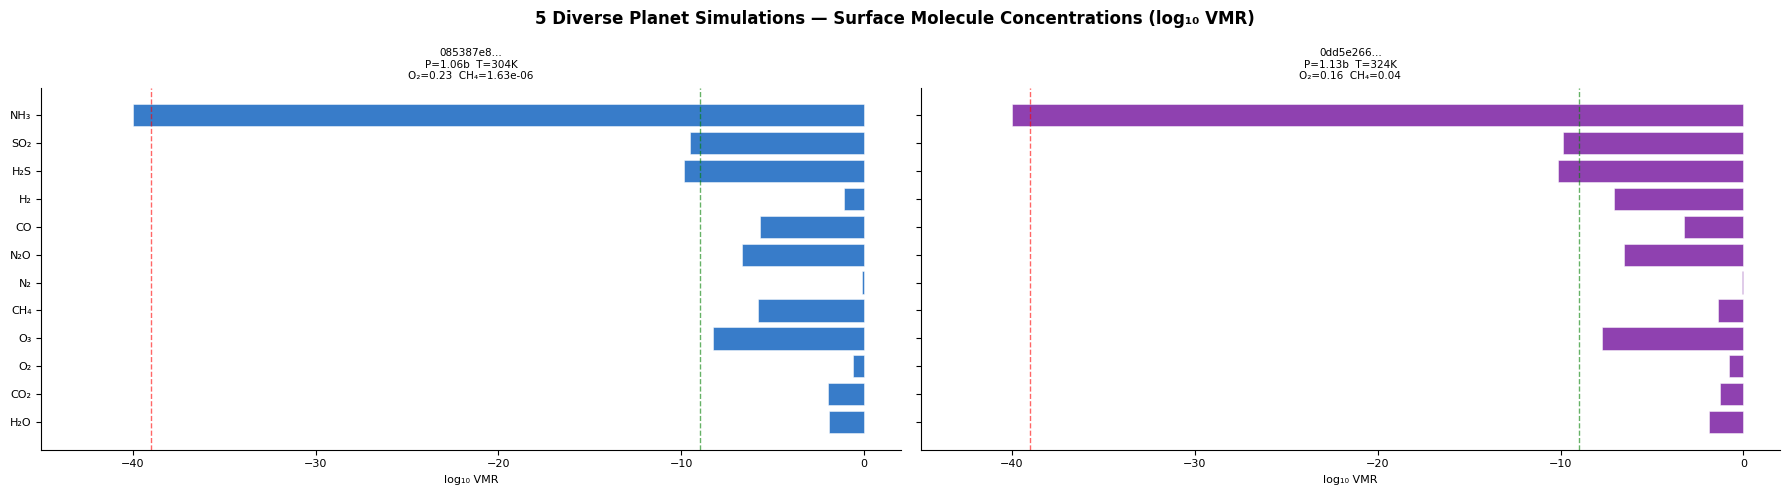

In [25]:
fig, axes = plt.subplots(1, len(samples), figsize=(18, 5), sharey=True)
fig.suptitle('5 Diverse Planet Simulations — Surface Molecule Concentrations (log₁₀ VMR)',
             fontsize=12, fontweight='bold')

palette = ['#1565C0','#7B1FA2','#2E7D32','#E65100','#4E342E']

for ax, (h, vec, m), color in zip(axes, samples, palette):
    bars = ax.barh(MOLECULE_LABELS, vec, color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.4)
    ax.axvline(-9,  color='green', ls='--', lw=1, alpha=0.6)
    ax.axvline(-39, color='red',   ls='--', lw=1, alpha=0.6)
    ax.set_xlim(-45, 2)
    p = m.get('pressure', '?')
    t = m.get('temperature', '?')
    conc = m.get('input_species_concentrations', {})
    o2  = conc.get('O2', '?')
    ch4 = conc.get('CH4', '?')
    ax.set_title(f'{h[:8]}...\nP={p:.2f}b  T={t:.0f}K\nO₂={o2}  CH₄={ch4}',
                 fontsize=7.5)
    ax.set_xlabel('log₁₀ VMR', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 9. End-to-End: How Files Map to the .npy Arrays

```
pyatmos_summary.csv
    └─ hash column → selects which planet directories to open

dir_N.tar.gz / Dir_alpha.tar.gz
    └─ {hash}/
        ├── parsed_clima_final.npy.npz      (101, 12)
        │       └─ transpose → (12, 101)   → spectra.npy[:, :, :]   CNN INPUT
        │
        ├── parsed_photochem_mixing_ratios.npy.npz  (102, 66)
        │       └─ row 0 (surface), cols [3,4,9,10,17,24,28,37,42,47,48]
        │          → log10 with floor=−40   → molecules.npy[:, 0-4,6-11]  CNN TARGETS
        │
        ├── mixing_ratios.dat
        │       └─ parse !Nitrogen line → log10  → molecules.npy[:, 5]   N2 TARGET
        │
        └── run_metadata.json
                └─ 11 scalar fields             → aux_params.npy          NOT USED IN MODEL
```

In [26]:
# Summary table
summary_table = pd.DataFrame([
    ['pyatmos_summary.csv', '124,314 rows × 18 cols', 'Sample selection index', 'NOT saved to .npy'],
    ['parsed_clima_final.npy.npz', '(101, 12) per sample', 'CLIMA atmospheric profile — model input features', 'spectra.npy  (N, 12, 101)'],
    ['parsed_photochem_mixing_ratios.npy.npz', '(102, 66) per sample', 'Chemical mixing ratios — model targets (11 molecules)', 'molecules.npy  (N, 12)'],
    ['mixing_ratios.dat', 'Text file', 'N₂ surface VMR — 12th molecule target', 'molecules.npy col 5'],
    ['run_metadata.json', '20 keys', 'Simulation input conditions (not used in training)', 'aux_params.npy  (N, 11)'],
], columns=['Source File', 'Shape / Size', 'Content', 'Output .npy'])

summary_table.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Source File,Shape / Size,Content,Output .npy
pyatmos_summary.csv,"124,314 rows × 18 cols",Sample selection index,NOT saved to .npy
parsed_clima_final.npy.npz,"(101, 12) per sample",CLIMA atmospheric profile — model input features,"spectra.npy (N, 12, 101)"
parsed_photochem_mixing_ratios.npy.npz,"(102, 66) per sample",Chemical mixing ratios — model targets (11 molecules),"molecules.npy (N, 12)"
mixing_ratios.dat,Text file,N₂ surface VMR — 12th molecule target,molecules.npy col 5
run_metadata.json,20 keys,Simulation input conditions (not used in training),"aux_params.npy (N, 11)"
